In [1]:
# Basic libraries 
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
import pickle
import os
import sys

PROJECT_ROOT = os.path.abspath("..")
sys.path.insert(0, PROJECT_ROOT)

from src.local_config import *
from src.utils import *

# Import data <br>
- Create algorithm to compute cointegrated pairs (pairs-det.py)
- Do human check on the pairs that the algorithm chose by plotting pairs and computing simple EDA

In [2]:
# Collect the raw Bloomberg price data and merge tech + commodities on Date.

"""
df1 = tech assets 
df2 = commodities assets 
df = tech + commodities merged together
"""

df1 = pd.read_csv(PROJECT_ROOT / "data/raw_data/tech.csv")
df2 = pd.read_csv(PROJECT_ROOT / "data/raw_data/commodities.csv")

df = pd.merge(df1, df2, how='left', on='Date')
df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y')
df = df.set_index('Date')
df = df.sort_index()

In [3]:
df.head()

,100 HK Equity,1024 HK Equity,1211 HK Equity,1347 HK Equity,1698 HK Equity,1810 HK Equity,20 HK Equity,2015 HK Equity,2382 HK Equity,241 HK Equity,...,2883 HK Equity,3668 HK Equity,386 HK Equity,3899 HK Equity,467 HK Equity,639 HK Equity,857 HK Equity,883 HK Equity,934 HK Equity,975 HK Equity
Date,,,,,,,,,,,,,,,,,,,,,
2015-01-01,NaN,NaN,10.117,10.24,NaN,NaN,NaN,NaN,13.38,5.09,...,13.46,NaN,6.25,6.15,0.867,1.686,8.60,10.44,6.21,3.40
2015-01-02,NaN,NaN,10.583,9.82,NaN,NaN,NaN,NaN,13.20,5.11,...,13.80,NaN,6.28,6.32,0.867,1.666,8.69,10.62,6.20,3.40
2015-01-05,NaN,NaN,10.583,9.69,NaN,NaN,NaN,NaN,13.32,4.97,...,13.98,NaN,6.36,6.52,0.867,1.746,8.74,10.64,6.03,3.35
2015-01-06,NaN,NaN,10.633,9.95,NaN,NaN,NaN,NaN,13.18,5.00,...,13.28,NaN,6.24,6.36,0.867,1.726,8.53,10.30,5.78,3.40
2015-01-07,NaN,NaN,9.733,9.85,NaN,NaN,NaN,NaN,12.58,4.97,...,13.36,NaN,6.24,6.34,0.867,1.726,8.57,10.28,5.91,3.30


### Ticker - Company Name
| Ticker (Tech) | Company (Tech)                     | Ticker (Energy/Materials) | Company (Energy/Materials)        |
|---------------|------------------------------------|---------------------------|-----------------------------------|
| 700 HK Equity | TENCENT HOLDINGS LTD              | 857 HK Equity             | PETROCHINA CO LTD-H               |
| 9988 HK Equity| ALIBABA GROUP HOLDING LTD         | 883 HK Equity             | CNOOC LTD-H                       |
| 1211 HK Equity| BYD CO LTD-H                      | 1088 HK Equity            | CHINA SHENHUA ENERGY CO-H         |
| 1810 HK Equity| XIAOMI CORP-CLASS B               | 2899 HK Equity            | ZIJIN MINING GROUP CO LTD-H       |
| 300 HK Equity | MIDEA GROUP CO LTD-H              | 386 HK Equity             | CHINA PETROLEUM & CHEMICAL-H      |
| 981 HK Equity | SEMICONDUCTOR MANUFACTURING-H     | 3993 HK Equity            | CMOC GROUP LTD-H                  |
| 9999 HK Equity| NETEASE INC                       | 2259 HK Equity            | ZIJIN GOLD INTERNATIONAL CO       |
| 3690 HK Equity| MEITUAN-CLASS B                   | 1378 HK Equity            | CHINA HONGQIAO GROUP LTD          |
| 9618 HK Equity| JD.COM INC-CLASS A                | 2600 HK Equity            | ALUMINUM CORP OF CHINA LTD-H      |
| 9888 HK Equity| BAIDU INC-CLASS A                 | 1898 HK Equity            | CHINA COAL ENERGY CO-H            |
| 9961 HK Equity| TRIP.COM GROUP LTD                | 1772 HK Equity            | GANFENG LITHIUM GROUP CO L-H      |
| 6690 HK Equity| HAIER SMART HOME CO LTD-H         | 1787 HK Equity            | SHANDONG GOLD MINING CO LT-H      |
| 1024 HK Equity| KUAISHOU TECHNOLOGY               | 1171 HK Equity            | YANKUANG ENERGY GROUP CO-H        |
| 1347 HK Equity| HUA HONG SEMICONDUCTOR LTD-H      | 358 HK Equity             | JIANGXI COPPER CO LTD-H           |
| 2015 HK Equity| LI AUTO INC-CLASS A               | 1818 HK Equity            | ZHAOJIN MINING INDUSTRY CO-H      |
| 6618 HK Equity| JD HEALTH INTERNATIONAL INC       | 1208 HK Equity            | MMG LTD                           |
| 992 HK Equity | LENOVO GROUP LTD                  | 2099 HK Equity            | CHINA GOLD INTERNATIONAL RES      |
| 9866 HK Equity| NIO INC-CLASS A                   | 2883 HK Equity            | CHINA OILFIELD SERVICES-H         |
| 9868 HK Equity| XPENG INC - CLASS A SHARES        | 2788 HK Equity            | CHUANGXIN INDUSTRIES HOLDING      |
| 1698 HK Equity| TENCENT MUSIC ENT - CLASS A       | 3939 HK Equity            | WANGUO GOLD GROUP LTD             |
| 9660 HK Equity| HORIZON ROBOTICS INC              | 3858 HK Equity            | JIAXIN INTERNATIONAL RESOURC      |
| 20 HK Equity  | SENSE TIME GROUP INC-CLASS B      | 1258 HK Equity            | CHINA NONFERROUS MINING CORP      |
| 9626 HK Equity| BILIBILI INC-CLASS Z              | 3668 HK Equity            | YANCOAL AUSTRALIA LTD             |
| 241 HK Equity | ALIBABA HEALTH INFORMATION TECH   | 3330 HK Equity            | LINGBAO GOLD GROUP CO LTD-H       |
| 9863 HK Equity| ZHEJIANG LEAPMOTOR TECHNOLOGY-H   | 1164 HK Equity            | CGN MINING CO LTD                 |
| 2382 HK Equity| SUNNY OPTICAL TECH                | 2689 HK Equity            | NINE DRAGONS PAPER HOLDINGS       |
| 285 HK Equity | BYD ELECTRONIC INTL CO LTD        | 2386 HK Equity            | SINOPEC ENGINEERING GROUP-H       |
| 780 HK Equity | TONGCHENG TRAVEL HOLDINGS LTD     | 2610 HK Equity            | NANSHAN ALUMINIUM INTERNATIO      |
| 3888 HK Equity| KINGSOFT CORP LTD                 | 3899 HK Equity            | CIMC ENRIC HOLDINGS LTD           |
| 268 HK Equity | KINGDEE INTERNATIONAL SOFTWARE    | 189 HK Equity             | DONGYUE GROUP                     |

*We keep tech and commodities pairs separate from each other to mitigate the issue of spurious regressions from occurring*

In [4]:
# Set the time index for our respective dataframes
df1['Date'] = pd.to_datetime(df1['Date'], dayfirst=True)
df1 = df1.set_index('Date')

df2['Date'] = pd.to_datetime(df2['Date'], dayfirst=True)
df2 = df2.set_index('Date')

In [5]:
"""
Universe rule. We keep the full 2015 start but no longer require at least 50%
history asd wna: names that listed later (e.g. Alibaba 2019, Xiaomi 2018) are admitted as
long as they cover at least MIN_COVERAGE of the sample. Genuinely empty tickers are
dropped; forward-fill covers internal gaps, while leading pre-listing gaps stay NaN
(correct -- no price exists before a stock listed). Each pair is later cointegration-
tested on its own overlapping window, and the rolling-stability filter (nb2) still
decides which pairs are actually tradeable.

MIN_COVERAGE is tunable: lower it to admit more (shorter-history) names; raise it
toward 1.0 to require (near-)full 2015-2025 history.
"""

START_DATE = "2015-01-01"
MIN_COVERAGE = 0.50

df1 = df1.loc[START_DATE:'2026-01-01']
df1 = df1.dropna(axis=1, how="all")                    # drop genuinely empty tickers
df1 = df1.loc[:, df1.notna().mean() >= MIN_COVERAGE]
df1 = df1.ffill()
df1.head()

,1211 HK Equity,1347 HK Equity,1810 HK Equity,2382 HK Equity,241 HK Equity,285 HK Equity,3690 HK Equity,700 HK Equity,780 HK Equity,9618 HK Equity,981 HK Equity,992 HK Equity,9988 HK Equity,9999 HK Equity
Date,,,,,,,,,,,,,,
2015-01-01,10.117,10.24,NaN,13.38,5.09,7.50,NaN,103.700,NaN,NaN,7.1,10.20,NaN,NaN
2015-01-02,10.583,9.82,NaN,13.20,5.11,7.81,NaN,103.976,NaN,NaN,7.4,10.22,NaN,NaN
2015-01-05,10.583,9.69,NaN,13.32,4.97,8.01,NaN,104.621,NaN,NaN,7.4,10.06,NaN,NaN
2015-01-06,10.633,9.95,NaN,13.18,5.00,7.80,NaN,110.613,NaN,NaN,7.1,10.08,NaN,NaN
2015-01-07,9.733,9.85,NaN,12.58,4.97,8.22,NaN,114.669,NaN,NaN,7.2,10.42,NaN,NaN


In [6]:
# Same rule for commodities (uses START_DATE / MIN_COVERAGE from the tech cell).
df2 = df2.loc[START_DATE:'2026-01-01']
df2 = df2.dropna(axis=1, how="all")
df2 = df2.loc[:, df2.notna().mean() >= MIN_COVERAGE]
df2 = df2.ffill()
df2.tail()

,1164 HK Equity,1208 HK Equity,1258 HK Equity,1378 HK Equity,1772 HK Equity,1787 HK Equity,1818 HK Equity,189 HK Equity,1907 HK Equity,2099 HK Equity,...,2883 HK Equity,3668 HK Equity,386 HK Equity,3899 HK Equity,467 HK Equity,639 HK Equity,857 HK Equity,883 HK Equity,934 HK Equity,975 HK Equity
Date,,,,,,,,,,,,,,,,,,,,,
2025-11-25,2.91,6.74,13.97,30.52,49.68,34.06,29.16,10.30,2.21,138.3,...,7.44,27.00,4.41,7.87,0.485,3.10,8.69,21.24,4.11,9.87
2025-11-26,2.93,6.78,13.70,29.92,49.26,33.94,28.72,10.37,2.20,138.9,...,7.31,27.50,4.42,8.07,0.490,3.07,8.70,21.06,4.14,9.87
2025-11-27,2.95,6.80,14.54,30.66,47.96,34.36,28.72,10.40,2.21,141.3,...,7.29,27.46,4.47,7.97,0.490,2.93,8.74,21.34,4.16,10.18
2025-11-28,3.00,6.91,14.95,30.86,48.98,34.58,29.06,10.89,2.22,148.6,...,7.25,27.34,4.41,7.99,0.495,2.91,8.68,21.18,4.15,10.29
2025-12-01,3.05,7.80,16.50,31.78,48.62,35.98,30.14,10.80,2.25,165.5,...,7.42,27.60,4.45,8.21,0.495,2.89,8.78,21.44,4.15,10.41


In [7]:
# Transforming raw prices into log prices
df1 = np.log(df1)
df2 = np.log(df2)

Therefore, with tech, we can have 45 potential pairs and with commodities we can have 253 (*210*) potential pairs, given:
$$
\text{Pairs} = \frac{(n\times(n-1))}{2}
$$

### Calculate Returns and run basic EDA (identify outliers and form correlation matrix)

$$
r_t = ln(\frac{P_{t}}{P_{t-1}})
$$

In [8]:
# For tech. dropna(how="all") keeps rows where at least one name has a return, so a
# later-listed name's leading (pre-listing) NaNs no longer truncate the whole panel.
# Downstream EDA (winsorize, z-score flags, correlation) is NaN-tolerant and works
# per column / pairwise.
tech_returns = (df1 - df1.shift(1)).dropna(how="all")
print(tech_returns)

# For commodities
comm_returns = (df2 - df2.shift(1)).dropna(how="all")
print(comm_returns)

            1211 HK Equity  1347 HK Equity  1810 HK Equity  2382 HK Equity  \
Date                                                                         
2015-01-02        0.045032       -0.041880             NaN       -0.013544   
2015-01-05        0.000000       -0.013327             NaN        0.009050   
2015-01-06        0.004713        0.026478             NaN       -0.010566   
2015-01-07       -0.088440       -0.010101             NaN       -0.046592   
2015-01-08        0.011949        0.005063             NaN       -0.069106   
...                    ...             ...             ...             ...   
2025-12-25        0.000000        0.000000        0.000000        0.000000   
2025-12-26        0.000000        0.000000        0.000000        0.000000   
2025-12-29        0.036711        0.013899       -0.016453       -0.027996   
2025-12-30        0.005136        0.037919        0.020016        0.021842   
2025-12-31       -0.023323       -0.012705       -0.001526      

### Splitting data
Before proceeding, we should split our data into a test and training set to ensure that our strategy has some rigour on OOS performance (70/30 split)

In [9]:
# 70/30 train-test split. Over the full 2015-2025 window, the fixed date
# 2022-10-01 gives roughly a 70/30 in-sample/out-of-sample split.
split_date = "2022-10-01"

df1_is = df1.loc[df1.index < split_date].copy()
df1_oos = df1.loc[df1.index >= split_date].copy()

df2_is = df2.loc[df2.index < split_date].copy()
df2_oos = df2.loc[df2.index >= split_date].copy()

tech_returns_is = tech_returns.loc[tech_returns.index < split_date].copy()
tech_returns_oos = tech_returns.loc[tech_returns.index >= split_date].copy()

comm_returns_is = comm_returns.loc[comm_returns.index < split_date].copy()
comm_returns_oos = comm_returns.loc[comm_returns.index >= split_date].copy()

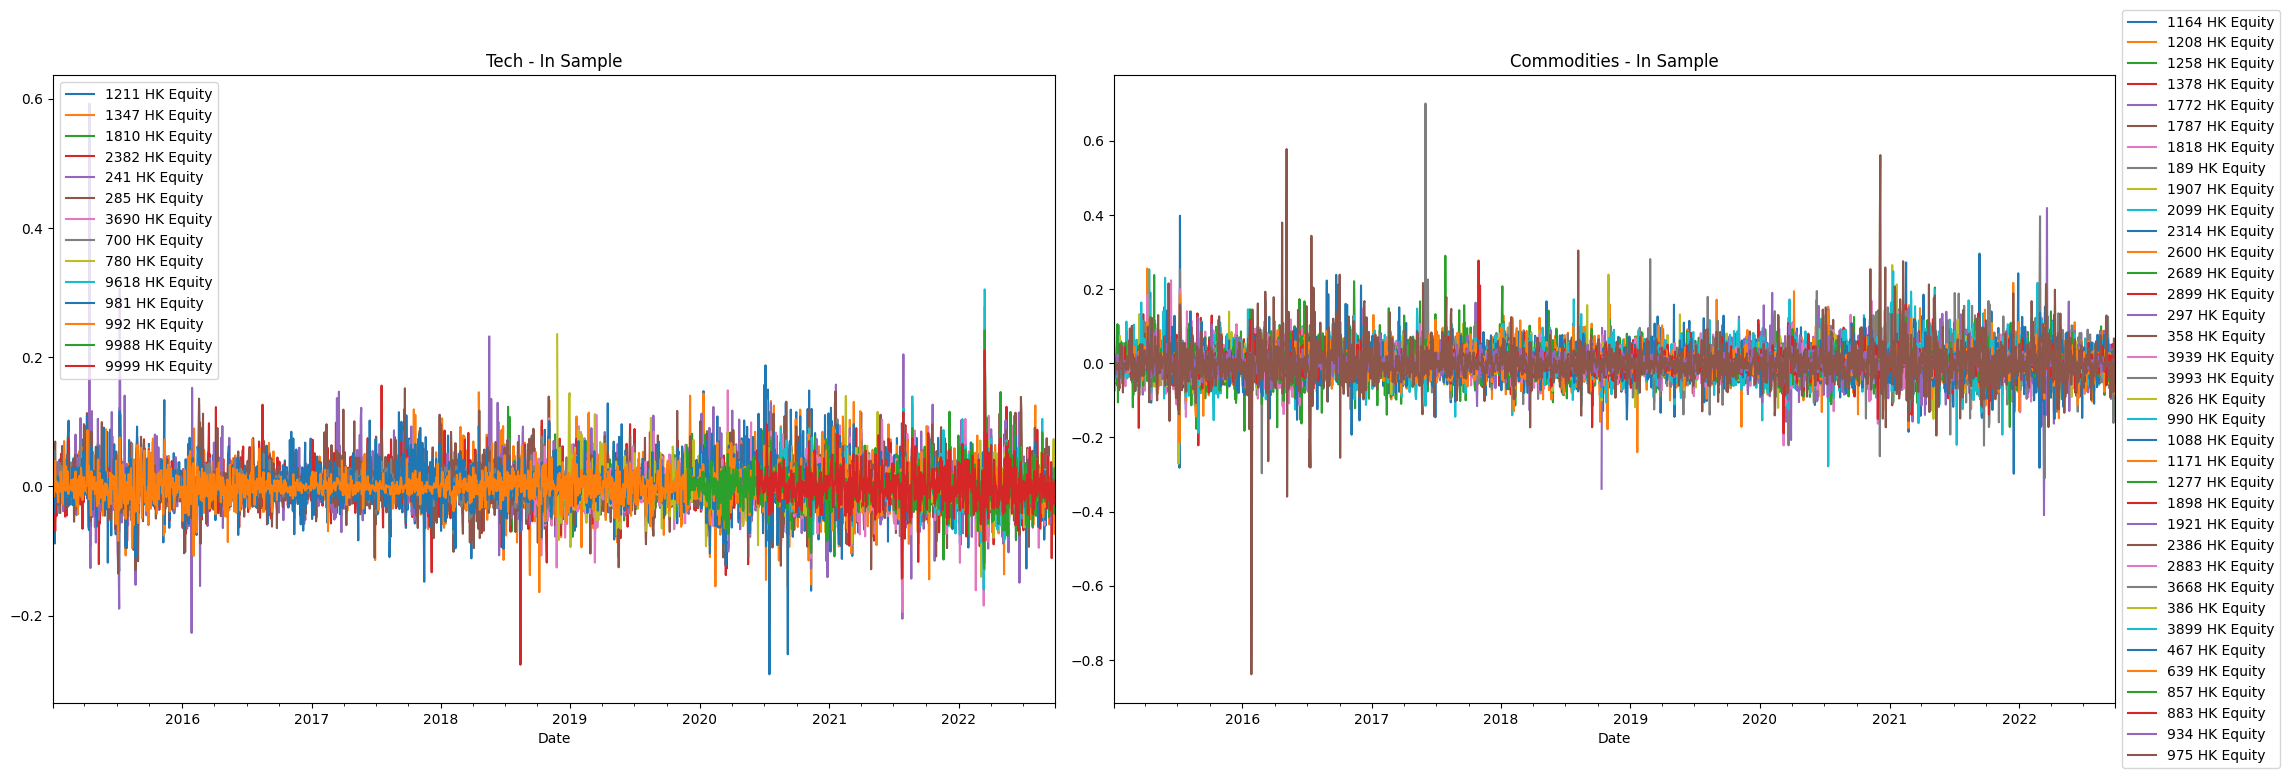

In [10]:
# Checking for outliers visually

fig, axes = plt.subplots(1, 2, figsize=(23, 8))

tech_returns_is.plot(ax=axes[0])
axes[0].set_title("Tech - In Sample")

comm_returns_is.plot(ax=axes[1])
axes[1].set_title("Commodities - In Sample")
axes[1].legend(loc='center left', bbox_to_anchor=(1, 0.5))

plt.tight_layout()
plt.show()

In [11]:
# Checking individual plots
output_folder = PROJECT_ROOT / "outputs/plots/time_series"
os.makedirs(output_folder, exist_ok=True)

for asset in comm_returns_is.columns:
    
    plt.figure(figsize=(10, 4))
    
    comm_returns_is[asset].plot()
    plt.title(asset)
    plt.xlabel("Date")
    plt.ylabel("Returns")
    
    filename = asset.replace(" ", "_") + ".png"
    filepath = os.path.join(output_folder, filename)
    
    plt.savefig(filepath)
    plt.close()

for asset in tech_returns_is.columns:
    
    plt.figure(figsize=(10, 4))
    
    tech_returns_is[asset].plot()
    plt.title(asset)
    plt.xlabel("Date")
    plt.ylabel("Returns")
    
    filename = asset.replace(" ", "_") + ".png"
    filepath = os.path.join(output_folder, filename)
    
    plt.savefig(filepath)
    plt.close()

"""
Looking at the plots individually, we find that 189 and 1378 HK Equity have
0 change for an extended period of time, hence we remove it.
"""

comm_returns = comm_returns.drop(["189 HK Equity", "1378 HK Equity"], axis=1)
comm_returns.columns

Index(['1164 HK Equity', '1208 HK Equity', '1258 HK Equity', '1772 HK Equity',
       '1787 HK Equity', '1818 HK Equity', '1907 HK Equity', '2099 HK Equity',
       '2314 HK Equity', '2600 HK Equity', '2689 HK Equity', '2899 HK Equity',
       '297 HK Equity', '358 HK Equity', '3939 HK Equity', '3993 HK Equity',
       '826 HK Equity', '990 HK Equity', '1088 HK Equity', '1171 HK Equity',
       '1277 HK Equity', '1898 HK Equity', '1921 HK Equity', '2386 HK Equity',
       '2883 HK Equity', '3668 HK Equity', '386 HK Equity', '3899 HK Equity',
       '467 HK Equity', '639 HK Equity', '857 HK Equity', '883 HK Equity',
       '934 HK Equity', '975 HK Equity'],
      dtype='str')

In [12]:
# Check for outliers with the > 5 standard deviations rule
tech_flags = flag_extreme_zscore(tech_returns_is)
tech_outliers = tech_returns_is[tech_flags].stack().dropna()
print("Tech outlier assets before winsorization:",
      list(tech_outliers.index.get_level_values(1).unique()))

comm_flags = flag_extreme_zscore(comm_returns_is)
comm_outliers = comm_returns_is[comm_flags].stack().dropna()
print("Comm outlier assets before winsorization:",
      list(comm_outliers.index.get_level_values(1).unique()))

Tech outlier assets before winsorization: ['241 HK Equity', '2382 HK Equity', '992 HK Equity', '780 HK Equity', '981 HK Equity', '1347 HK Equity', '1211 HK Equity', '3690 HK Equity', '700 HK Equity', '1810 HK Equity', '9618 HK Equity', '9988 HK Equity', '9999 HK Equity']
Comm outlier assets before winsorization: ['1378 HK Equity', '358 HK Equity', '3993 HK Equity', '826 HK Equity', '1171 HK Equity', '2883 HK Equity', '990 HK Equity', '2099 HK Equity', '1277 HK Equity', '2899 HK Equity', '3939 HK Equity', '934 HK Equity', '297 HK Equity', '1164 HK Equity', '639 HK Equity', '1818 HK Equity', '189 HK Equity', '2386 HK Equity', '1258 HK Equity', '883 HK Equity', '2689 HK Equity', '975 HK Equity', '467 HK Equity', '1088 HK Equity', '2600 HK Equity', '1772 HK Equity', '1208 HK Equity', '3668 HK Equity', '857 HK Equity', '386 HK Equity', '3899 HK Equity', '1921 HK Equity', '1907 HK Equity', '1898 HK Equity', '2314 HK Equity']


Deal with outliers by winsorization

In [13]:
# Winsorize returns to mitigate data errors and extreme spikes
tech_returns_win = winsorize(tech_returns_is)
comm_returns_win = winsorize(comm_returns_is)

In [14]:
# Check whether there are any outliers remaining after winsorization
tech_flags_win = flag_extreme_zscore(tech_returns_win)
tech_outliers_win = tech_returns_win[tech_flags_win].stack().dropna()
print("Tech remaining outlier assets:",
      list(tech_outliers_win.index.get_level_values(1).unique()))

comm_flags_win = flag_extreme_zscore(comm_returns_win)
comm_outliers_win = comm_returns_win[comm_flags_win].stack().dropna()
print("Comm remaining outlier assets:",
      list(comm_outliers_win.index.get_level_values(1).unique()))

Tech remaining outlier assets: []
Comm remaining outlier assets: []


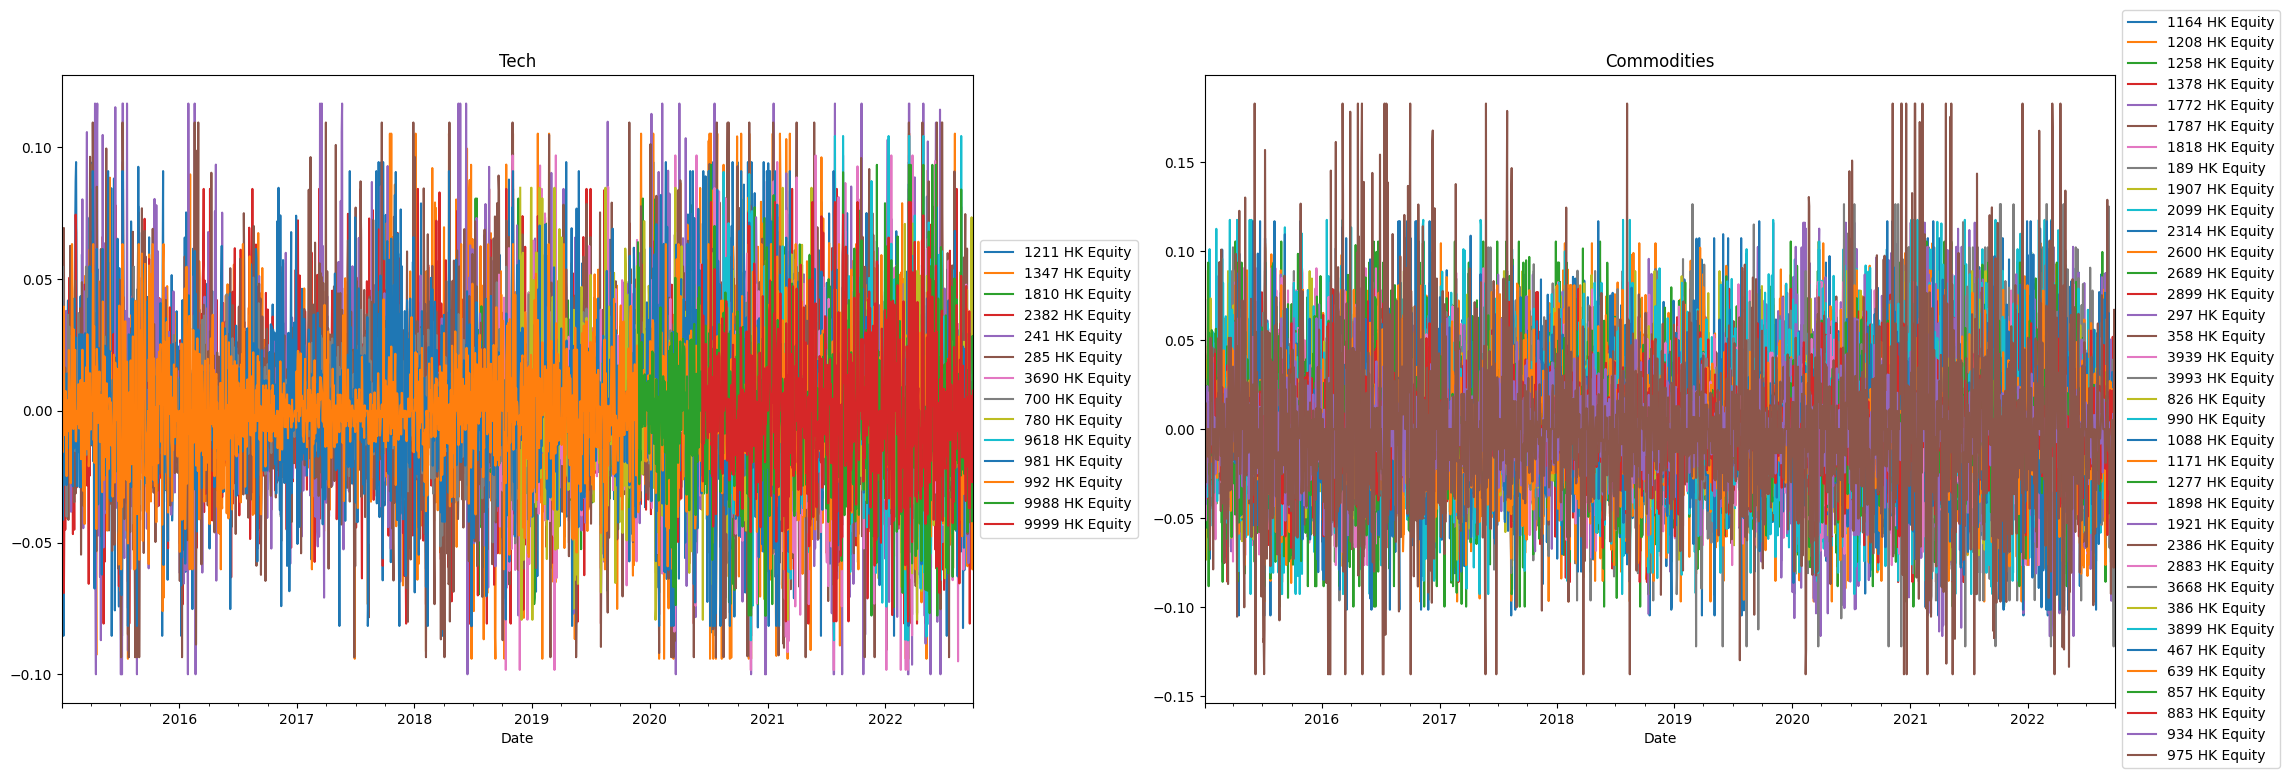

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(23, 8))

tech_returns_win.plot(ax=axes[0], legend=True)
axes[0].set_title("Tech")
axes[0].legend(loc='center left', bbox_to_anchor=(1, 0.5))

comm_returns_win.plot(ax=axes[1], legend=True)
axes[1].set_title("Commodities")
axes[1].legend(loc='center left', bbox_to_anchor=(1, 0.5))

plt.tight_layout()
plt.show()

### Correlation Matrix 

Simple analysis and see whether some equities are highly correlated or not to identify any key patterns between them

In [16]:
# Label tickers with company names for the correlation matrices.
# Names come from the shared src/ticker_names.py map (single source of truth),
# so every ticker in the universe -- including new ones from the re-pull
# (e.g. 975 Mongolian Mining, 826 Tiangong) -- is labelled consistently.
from src.ticker_names import label_ticker

tech_returns_win = tech_returns_win.rename(columns=label_ticker)
comm_returns_win = comm_returns_win.rename(columns=label_ticker)

In [17]:
# Forming correlation matrices
tech_corr_matrix = tech_returns_win.corr()
comm_corr_matrix = comm_returns_win.corr()

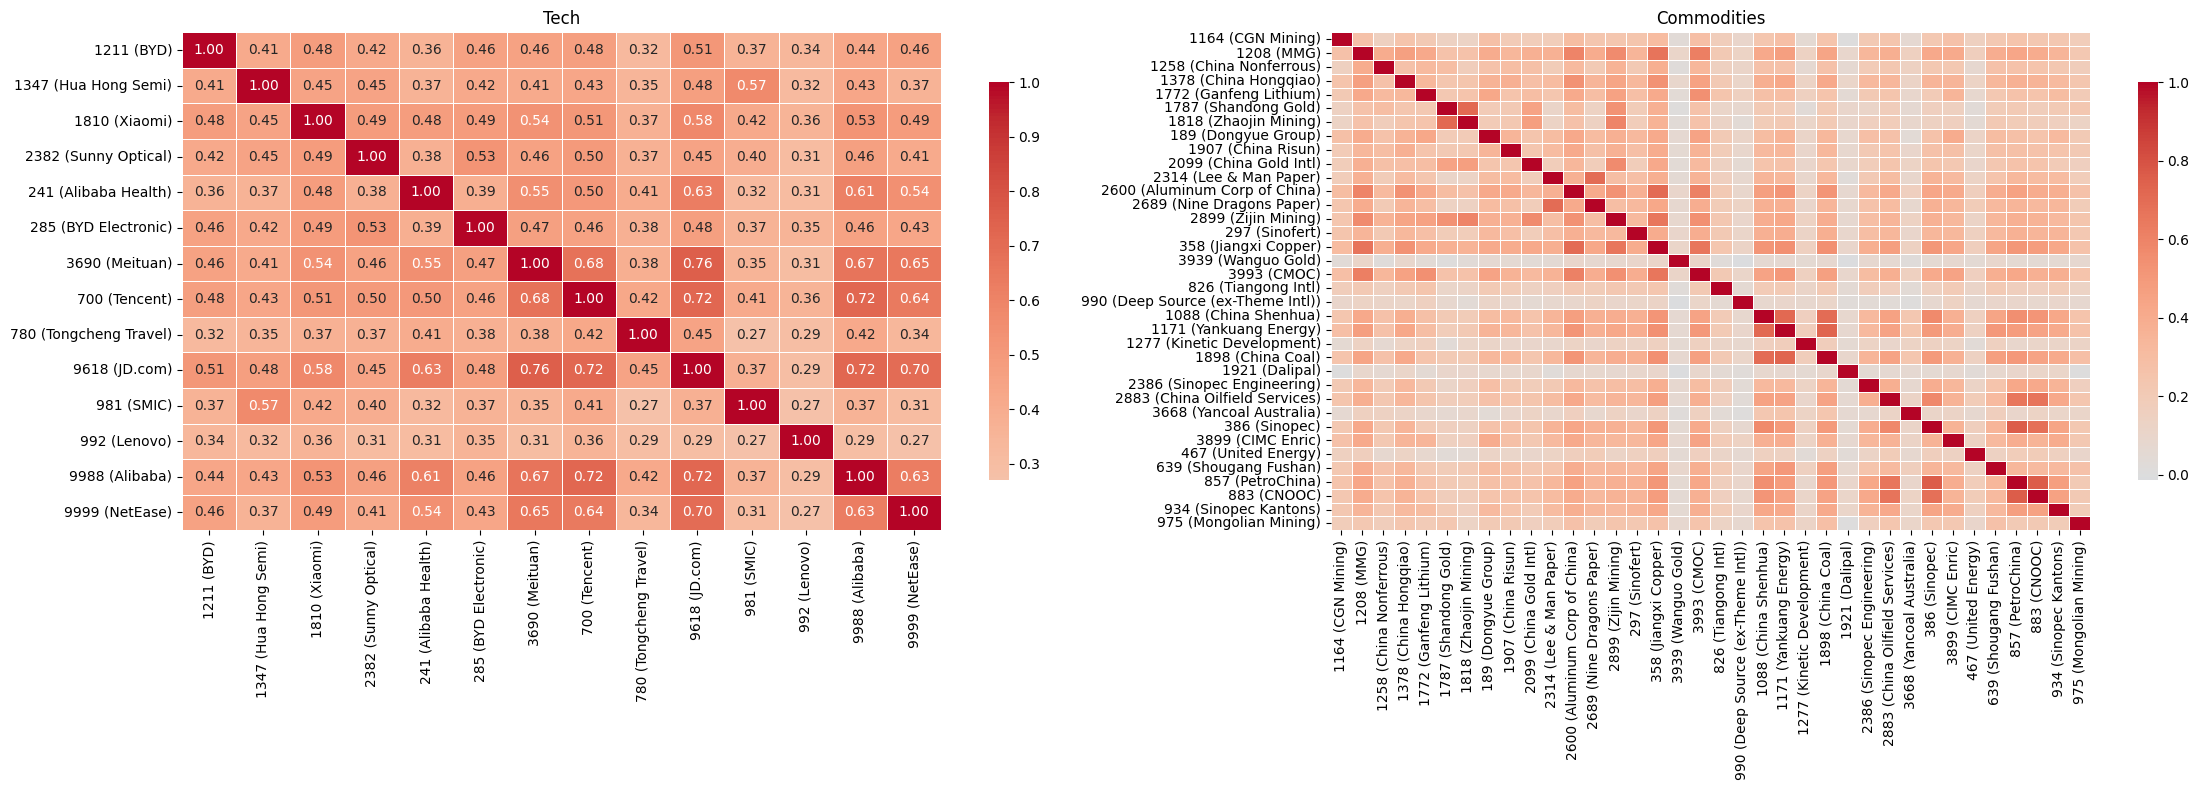

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(23, 8))

# Tech heatmap
sns.heatmap(
    tech_corr_matrix,
    ax=axes[0],
    cmap="coolwarm",
    annot=True,        
    fmt=".2f", 
    center=0,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)
axes[0].set_title("Tech")

# Commodities heatmap
sns.heatmap(
    comm_corr_matrix,
    ax=axes[1],
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)
axes[1].set_title("Commodities")

plt.tight_layout()
plt.show()

In [19]:
# Save data 

df1_is.to_csv(PROJECT_ROOT / "data/df1_is")
df1_oos.to_csv(PROJECT_ROOT / "data/df1_oos")

df2_is.to_csv(PROJECT_ROOT / "data/df2_is")
df2_oos.to_csv(PROJECT_ROOT / "data/df2_oos")